In [ ]:
# ── Section 1: Scraper Reference Code (Local Only) ────────────────────────────
# Full async Playwright scraper for the Fulton County qPublic portal.
# Scrapes 400 randomly sampled parcels from the Summerhill neighbourhood,
# extracting owner info, sale history, multi-year valuations, and property attributes.
#
# Key design decisions:
#   - CONCURRENCY = 2: two parallel browser pages to avoid rate limiting
#   - RETRIES = 3: auto-retries with exponential backoff on failure
#   - SAVE_EVERY = 25: checkpoints progress to JSON so scrape can be resumed
#   - random.seed(42): reproducible parcel sample across runs
#
# Helper functions:
#   - norm(): collapses whitespace in extracted strings
#   - parcel_to_keyvalue(): formats parcel IDs into qPublic URL key format
#   - pick() / pick_contains(): safely extracts fields from the scraped key-value dict
#   - extract_kv_dom(): pulls all label-value pairs from dl, table, and div elements
#   - extract_all_tables(): extracts structured tables with headers and rows
#   - click_all_tabs(): clicks each qPublic tab (Summary, Sales, Valuation, etc.)
#     to force lazy-loaded content to render before extraction
#   - parse_sales_from_tables(): identifies and parses the sales history table
#   - parse_valuation_from_tables(): identifies and parses multi-year valuation table
#   - scrape_one(): orchestrates a full scrape for a single parcel URL
#   - run_all(): async task runner managing concurrency, retries, and checkpointing
#   - main(): entry point — loads parcel IDs, resumes from checkpoint, saves final Excel
#
# Output: styled qpublic_400_parcels_v2.xlsx + qpublic_400_parcels_v2.csv
# ─────────────────────────────────────────────────────────────────────────────

In [2]:
# import os, re, random, asyncio, json, glob
# import pandas as pd
# from urllib.parse import quote_plus
# from openpyxl.styles import Font, PatternFill, Alignment
# from playwright.async_api import async_playwright
#
# OUTPUT_XLSX   = "qpublic_400_parcels_v2.xlsx"
# OUTPUT_CSV    = "qpublic_400_parcels_v2.csv"
# PROGRESS_FILE = "scrape_progress.json"
# Q        = 581425691
# BASE_URL = (
#     f"https://qpublic.schneidercorp.com/Application.aspx?"
#     f"AppID=936&LayerID=18251&PageTypeID=4&PageID=8156&Q={Q}&KeyValue={{KEY}}"
# )
# SAMPLE_SIZE = 400
# CONCURRENCY = 2
# RETRIES     = 3
# SAVE_EVERY  = 25
#
# def norm(s):
#     return re.sub(r"\s+", " ", (s or "").strip())
# def parcel_to_keyvalue(pid):
#     s = norm(str(pid))
#     return s if "+" in s else s.replace(" ", "+")
# def pick(d, *keys):
#     for k in keys:
#         v = d.get(k, "")
#         if isinstance(v, str) and v.strip():
#             return norm(v)
#     return ""
# def pick_contains(kv, *needles):
#     nl = [n.lower() for n in needles if n]
#     for k, v in kv.items():
#         if all(n in (k or "").lower() for n in nl):
#             if isinstance(v, str) and v.strip():
#                 return norm(v)
#     return ""
# async def extract_kv_dom(fr):
#     return await fr.evaluate("""
#     () => {
#       const out = {};
#       const clean = s => (s||"").replace(/\\s+/g," ").trim();
#       document.querySelectorAll("dl").forEach(dl => {
#         const dts = dl.querySelectorAll("dt");
#         const dds = dl.querySelectorAll("dd");
#         if(dts.length && dts.length===dds.length)
#           for(let i=0;i<dts.length;i++){
#             const k=clean(dts[i].innerText), v=clean(dds[i].innerText);
#             if(k&&v&&!(k in out)) out[k]=v;
#           }
#       });
#       document.querySelectorAll("table tr").forEach(tr => {
#         const cells=tr.querySelectorAll("th,td");
#         if(cells.length===2){
#           const k=clean(cells[0].innerText), v=clean(cells[1].innerText);
#           if(k&&v&&k.length<=100&&v.length<=400&&!(k in out)) out[k]=v;
#         }
#         if(cells.length===4){
#           const k1=clean(cells[0].innerText),v1=clean(cells[1].innerText);
#           const k2=clean(cells[2].innerText),v2=clean(cells[3].innerText);
#           if(k1&&v1&&k1.length<=100&&!(k1 in out)) out[k1]=v1;
#           if(k2&&v2&&k2.length<=100&&!(k2 in out)) out[k2]=v2;
#         }
#       });
#       document.querySelectorAll("div,section").forEach(el => {
#         const kids=Array.from(el.children);
#         if(kids.length===2){
#           const k=clean(kids[0].innerText), v=clean(kids[1].innerText);
#           if(k&&v&&k.length<=100&&v.length<=400&&!(k in out)) out[k]=v;
#         }
#       });
#       return out;
#     }
#     """)
# async def extract_all_tables(fr):
#     return await fr.evaluate("""
#     () => {
#       const clean = s => (s||"").replace(/\\s+/g," ").trim();
#       const tables = [];
#       document.querySelectorAll("table").forEach((t, ti) => {
#         const allRows = Array.from(t.querySelectorAll("tr"));
#         if (allRows.length < 2) return;
#         let headers = [], dataStartIdx = 0;
#         for (let i = 0; i < allRows.length; i++) {
#           const ths = Array.from(allRows[i].querySelectorAll("th")).map(th => clean(th.innerText));
#           if (ths.length > 0 && ths.some(h => h.length > 0)) { headers = ths; dataStartIdx = i+1; break; }
#         }
#         if (headers.length === 0) return;
#         const rows = [];
#         for (let i = dataStartIdx; i < allRows.length; i++) {
#           const cells = Array.from(allRows[i].querySelectorAll("th,td")).map(cell => clean(cell.innerText));
#           if (cells.length > 0 && cells.some(c => c.length > 0)) rows.push(cells);
#         }
#         if (rows.length > 0) tables.push({ index: ti, headers, rows });
#       });
#       return tables;
#     }
#     """)
# async def click_all_tabs(fr, page):
#     for tab in ["Summary","Land","Residential Improvement Information","Sales","Valuation","Commercial","Agriculture"]:
#         try:
#             clicked = await fr.evaluate(f"""() => {{
#               const el = Array.from(document.querySelectorAll("a,li,button,span"))
#                 .find(e => e.innerText && e.innerText.trim() === "{tab}");
#               if(el){{ el.click(); return true; }} return false;
#             }}""")
#             if clicked: await page.wait_for_timeout(1200)
#         except Exception: pass
# def parse_sales_from_tables(tables):
#     for table in tables:
#         headers = [h.lower() for h in table["headers"]]
#         if not any("sale date" in h for h in headers): continue
#         if not any("sale price" in h for h in headers): continue
#         def idx(needle):
#             for i,h in enumerate(headers):
#                 if needle in h: return i
#             return -1
#         i_date=idx("sale date"); i_price=idx("sale price"); i_inst=idx("instrument")
#         i_dbook=idx("deed book"); i_dpage=idx("deed page"); i_qual=idx("qualification")
#         i_validity=idx("validity"); i_grantee=idx("grantee"); i_grantor=idx("grantor"); i_rec=idx("recording")
#         def get(row,i): return row[i] if 0<=i<len(row) else ""
#         sales=[]
#         for row in table["rows"]:
#             sd=get(row,i_date); sp=get(row,i_price)
#             if not sd and not sp: continue
#             if sd.startswith("$") and not sp.startswith("$"): sd,sp=sp,sd
#             sales.append({"Sale Date":sd,"Sale Price":sp,"Instrument":get(row,i_inst),
#                 "Deed Book":get(row,i_dbook),"Deed Page":get(row,i_dpage),"Qualification":get(row,i_qual),
#                 "Sales Validity":get(row,i_validity),"Grantee":get(row,i_grantee),
#                 "Grantor":get(row,i_grantor),"Recording":get(row,i_rec)})
#         if sales: return sales
#     return []
# def parse_valuation_from_tables(tables):
#     for table in tables:
#         headers=table["headers"]
#         year_cols=[h for h in headers if re.match(r"^\d{4}$",h.strip())]
#         if len(year_cols)<2: continue
#         result={}; year_indices={}
#         for i,h in enumerate(headers):
#             if re.match(r"^\d{4}$",h.strip()): year_indices[h.strip()]=i; result[h.strip()]={}
#         for row in table["rows"]:
#             if not row: continue
#             label=row[0].lstrip("+=• ").strip()
#             if not label: continue
#             for year,col_idx in year_indices.items():
#                 if col_idx<len(row) and row[col_idx]: result[year][label]=row[col_idx]
#         if result: return result
#     return {}
# async def scrape_one(page, parcel_id):
#     key=parcel_to_keyvalue(parcel_id)
#     url=BASE_URL.format(KEY=quote_plus(key,safe="+"))
#     await page.goto(url,wait_until="domcontentloaded",timeout=180000)
#     await page.wait_for_timeout(5000)
#     fr=page.frames[0] if len(page.frames)>0 else page.main_frame
#     try: await fr.wait_for_selector("text=Parcel Number",timeout=30000)
#     except Exception: pass
#     await click_all_tabs(fr,page)
#     await page.wait_for_timeout(1500)
#     kv=await extract_kv_dom(fr); tables=await extract_all_tables(fr)
#     all_sales=parse_sales_from_tables(tables); valuation=parse_valuation_from_tables(tables)
#     latest_year=sorted(valuation.keys(),reverse=True)[0] if valuation else None
#     latest_val=valuation.get(latest_year,{}) if latest_year else {}
#     row={"ParcelID":norm(str(parcel_id)),"SourceURL":url,
#          "Parcel Number":pick(kv,"Parcel Number","Parcel No","Parcel ID"),
#          "Owner Name":pick(kv,"Owner","Owner Name","Primary Owner","Owner 1"),
#          "Mailing Address":pick(kv,"Mailing Address","Mail Address","Owner Address"),
#          "Location Address":pick(kv,"Location Address","Situs Address","Property Address","Address"),
#          "Property Class":pick(kv,"Property Class","Class","Property Type","Land Use"),
#          "Neighborhood":pick(kv,"Neighborhood","Nbhd"),"Tax District":pick(kv,"Tax District","Tax Dist","District"),
#          "Zoning":pick(kv,"Zoning","Zone"),"Acres":pick(kv,"Acres","Total Acres","Acreage"),
#          "Homestead":pick(kv,"Homestead"),"Exemptions":pick(kv,"Exemptions","Exemption"),
#          "Year Built":pick(kv,"Year Built","Yr Built"),"Effective Age":pick(kv,"Effective Age","Eff Age"),
#          "Total Sales Count":len(all_sales),"Latest Val Year":latest_year or "",
#          "Land Value":latest_val.get("Land Value",""),"Building Value":latest_val.get("Building Value",""),
#          "Total Value":latest_val.get("Total Value",""),"Assessed Value":latest_val.get("Assessed Value",""),
#          "LUC":latest_val.get("LUC",""),"Class":latest_val.get("Class","")}
#     for i,sale in enumerate(all_sales,start=1):
#         n=f"Sale{i}"
#         row[f"{n} Date"]=sale.get("Sale Date",""); row[f"{n} Price"]=sale.get("Sale Price","")
#         row[f"{n} Grantee"]=sale.get("Grantee",""); row[f"{n} Grantor"]=sale.get("Grantor","")
#         row[f"{n} Qualification"]=sale.get("Qualification",""); row[f"{n} Validity"]=sale.get("Sales Validity","")
#         row[f"{n} Instrument"]=sale.get("Instrument",""); row[f"{n} Deed Book"]=sale.get("Deed Book","")
#         row[f"{n} Deed Page"]=sale.get("Deed Page",""); row[f"{n} Recording"]=sale.get("Recording","")
#     for year in sorted(valuation.keys(),reverse=True):
#         ydata=valuation[year]
#         row[f"Val {year} LUC"]=ydata.get("LUC",""); row[f"Val {year} Class"]=ydata.get("Class","")
#         row[f"Val {year} Land Value"]=ydata.get("Land Value","")
#         row[f"Val {year} Building Value"]=ydata.get("Building Value","")
#         row[f"Val {year} Total Value"]=ydata.get("Total Value","")
#         row[f"Val {year} Assessed Value"]=ydata.get("Assessed Value","")
#     return row
# def save_progress(records):
#     with open(PROGRESS_FILE,"w") as f: json.dump(records,f)
# async def run_all(parcel_ids, existing):
#     sem=asyncio.Semaphore(CONCURRENCY); results=list(existing); failed=[]; counter={"done":0}
#     async with async_playwright() as p:
#         browser=await p.chromium.launch(headless=False,args=["--disable-blink-features=AutomationControlled"])
#         context=await browser.new_context(user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122 Safari/537.36",locale="en-US",viewport={"width":1280,"height":720})
#         async def worker(idx,pid):
#             async with sem:
#                 page=await context.new_page()
#                 try:
#                     for attempt in range(1,RETRIES+1):
#                         try:
#                             row=await scrape_one(page,pid); counter["done"]+=1
#                             print(f"[{idx:>3}/{len(parcel_ids)}] {pid} ✅  ({row.get('Total Sales Count',0)} sales)"); return row
#                         except Exception as e:
#                             if attempt==RETRIES:
#                                 print(f"[{idx:>3}/{len(parcel_ids)}] {pid} ❌  {e}"); failed.append(pid)
#                                 return {"ParcelID":norm(str(pid)),"Error":str(e)}
#                             await asyncio.sleep(2*attempt+random.random())
#                 finally: await page.close()
#         tasks=[asyncio.create_task(worker(i+1,pid)) for i,pid in enumerate(parcel_ids)]
#         for i,t in enumerate(asyncio.as_completed(tasks),start=1):
#             row=await t; results.append(row)
#             if i%SAVE_EVERY==0: save_progress(results); print(f"\n  💾 Checkpoint {i}/{len(parcel_ids)}\n")
#         await browser.close()
#     return results,failed
# async def main():
#     EXCEL_PATH=find_excel(); df_parcels=pd.read_excel(EXCEL_PATH,dtype=str)
#     all_ids=df_parcels["ParcelID"].dropna().str.strip().tolist()
#     existing,done_ids=[],set()
#     if os.path.exists(PROGRESS_FILE):
#         with open(PROGRESS_FILE) as f: existing=json.load(f)
#         done_ids={r["ParcelID"] for r in existing if not r.get("Error")}
#     selected_file="selected_parcels.json"
#     if os.path.exists(selected_file):
#         with open(selected_file) as f: selected=json.load(f)
#     else:
#         random.seed(42); selected=random.sample(all_ids,min(SAMPLE_SIZE,len(all_ids)))
#         with open(selected_file,"w") as f: json.dump(selected,f)
#     to_scrape=[p for p in selected if p not in done_ids]
#     all_results,failed=await run_all(to_scrape,existing); save_progress(all_results)
#     if failed: pd.DataFrame({"Failed_ParcelID":failed}).to_csv("failed_parcels.csv",index=False)
#     df=pd.DataFrame(all_results)
#     # ... column ordering and Excel styling (see qpublic_local.py for full code)
# if __name__ == "__main__":
#     asyncio.run(main())

print('ℹ️  Scraper reference only — run locally in VS Code.')

ℹ️  Scraper reference only — run locally in VS Code.


In [ ]:
# ── Section 2: Mount Google Drive ────────────────────────────────────────────
# Mounts the user's Google Drive so Colab can access the wrangled Excel file.
# Creates the working directory if it doesn't exist and sets it as cwd.

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_FOLDER = '/content/drive/My Drive/qpublic_scraper'
os.makedirs(DRIVE_FOLDER, exist_ok=True)
os.chdir(DRIVE_FOLDER)

print(f'✅ Working directory: {DRIVE_FOLDER}')
print(f'Files in folder: {os.listdir(DRIVE_FOLDER)}')

Mounted at /content/drive
✅ Working directory: /content/drive/My Drive/qpublic_scraper
Files in folder: ['Parcelunique.xlsx', 'qpublic_400_parcels_v2.xlsx', 'selected_parcels.json', 'qpublic_400_parcels_v2_wrangled.xlsx']


In [ ]:
# ── Section 3: Install Dependencies ──────────────────────────────────────────
# Installs required libraries for data processing and visualisation.
# pandas/openpyxl: DataFrame operations and Excel I/O
# matplotlib/seaborn: static chart rendering

In [4]:
%%capture
!pip install pandas openpyxl matplotlib seaborn
print('✅ Dependencies installed.')

In [ ]:
# ── Section 4: Load, Clean & Feature Engineer ─────────────────────────────────
# Reads the manually wrangled Excel sheet into a DataFrame.
# Key transformations:
#   - clean_price(): strips "$" and "," characters, coerces to float, nullifies $0/blanks
#   - Sale Pre Clean / Sale Post Clean: numeric versions of the two key sale price columns
#   - Adjusted Sale: percentage change from pre to post sale price, normalised to Effective Age
#     Formula: ((Sale Post - Sale Pre) / Sale Pre) * 100
#   - Delta: numeric cast of the Effective Age − Year Built gap
#   - Negative Delta rows dropped (data quality filter — age cannot precede build year)
#   - Rows missing either sale price dropped (required for all downstream analysis)

In [5]:
import pandas as pd
import numpy as np

INPUT_FILE = 'qpublic_400_parcels_v2_wrangled.xlsx'
SHEET_NAME = 'Sheet1'

# ── Load ─────────────────────────────────────────────────────────
df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME, dtype=str)
df.columns = [str(c).strip() for c in df.columns]
print(f'Loaded: {len(df)} rows × {len(df.columns)} columns')

# ── Helper: strip $ and commas → float ───────────────────────────
def clean_price(val):
    if pd.isna(val) or str(val).strip() in ('', 'N/A', 'nan', '$0', '0'):
        return np.nan
    cleaned = re.sub(r'[\$,]', '', str(val).strip())
    try:
        v = float(cleaned)
        return v if v > 0 else np.nan
    except ValueError:
        return np.nan

import re

# ── Clean prices ─────────────────────────────────────────────────
df['Sale Pre Clean']  = df['Sale Pre Price'].apply(clean_price)
df['Sale Post Clean'] = df['Sale Post Price'].apply(clean_price)

# ── Adjusted Sale = ((Post - Pre) * 100) / Pre ───────────────────
df['Adjusted Sale'] = np.where(
    df['Sale Pre Clean'].notna() & df['Sale Post Clean'].notna() & (df['Sale Pre Clean'] > 0),
    ((df['Sale Post Clean'] - df['Sale Pre Clean']) * 100) / df['Sale Pre Clean'],
    np.nan
)

# ── Delta as numeric ─────────────────────────────────────────────
df['Delta'] = pd.to_numeric(df['Delta'], errors='coerce')

# ── Year Built & Effective Age as numeric ─────────────────────────
df['Year Built']    = pd.to_numeric(df['Year Built'],    errors='coerce')
df['Effective Age'] = pd.to_numeric(df['Effective Age'], errors='coerce')

# ── Summary ──────────────────────────────────────────────────────
valid = df.dropna(subset=['Sale Pre Clean', 'Sale Post Clean', 'Adjusted Sale'])
print(f'\nRows with both Sale Pre & Post prices : {len(valid)}')
print(f'Adjusted Sale range : {valid["Adjusted Sale"].min():.1f}% to {valid["Adjusted Sale"].max():.1f}%')
print(f'Adjusted Sale mean  : {valid["Adjusted Sale"].mean():.1f}%')
print('\n✅ DataFrame ready.')
df.head(500)

Loaded: 400 rows × 27 columns

Rows with both Sale Pre & Post prices : 57
Adjusted Sale range : -100.0% to 4712.5%
Adjusted Sale mean  : 374.0%

✅ DataFrame ready.


,ParcelID,Year Built,Effective Age,Full Bath/Half Bath,Bedrooms,Acres,Square Feet,Sale1 Date,Sale1 Price,Sale2 Date,...,Sale6 Date,Sale6 Price,Sale Pre Date,Sale Pre Price,Sale Post Date,Sale Post Price,Delta,Sale Pre Clean,Sale Post Clean,Adjusted Sale
0,14 004400071083,1925.0,1965.0,3/0,4,NaN,NaN,5/15/2025,$10,9/11/2001,...,2/27/1990,$0,NaN,NaN,2/27/1990,$0,40.0,NaN,NaN,NaN
1,14 004300020172,1981.0,2010.0,2/1,3,0.1343,1957,6/2/2017,"$565,000",6/6/2014,...,8/30/1999,"$30,000",5/31/2002,"$271,600",8/6/2013,"$304,162",29.0,271600.0,304162.0,11.988954
2,14 004300010025,1920.0,2010.0,1/1,3,NaN,NaN,12/15/2006,"$273,900",5/22/2003,...,NaN,NaN,12/15/2006,"$273,900",NaN,NaN,90.0,273900.0,NaN,NaN
3,14 005300091022,1920.0,1965.0,2/0,3,NaN,NaN,12/10/2021,"$435,000",9/1/1999,...,NaN,NaN,NaN,NaN,6/9/1986,"$63,360",45.0,NaN,63360.0,NaN
4,14 004300040758,1920.0,1980.0,2/0,3,NaN,NaN,11/2/2021,$10,5/28/2015,...,6/13/2000,"$208,000",NaN,NaN,6/13/2000,"$208,000",60.0,NaN,208000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,14 004400040633,1920.0,1950.0,1/0,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN
396,14 004300050047,1920.0,1970.0,2/0,3,NaN,NaN,2/12/1999,$100,10/5/1988,...,NaN,NaN,NaN,NaN,10/5/1988,"$73,350",50.0,NaN,73350.0,NaN
397,14 005300090909,2005.0,0.0,3/1,4,NaN,NaN,6/1/2018,"$555,000",4/15/2014,...,12/29/2004,"$349,900",NaN,NaN,12/29/2004,"$349,900",-2005.0,NaN,349900.0,NaN
398,14 004400070960,1910.0,1975.0,3/0,4,NaN,NaN,6/2/2008,"$405,000",11/14/2005,...,3/26/1982,"$29,000",NaN,NaN,3/26/1982,"$29,000",65.0,NaN,29000.0,NaN


In [6]:
# Remove rows where Delta is negative (Effective Age < Year Built — invalid data)
before = len(df)
df = df[df['Delta'].isna() | (df['Delta'] >= 0)]
print(f'Removed {before - len(df)} rows with negative Delta.')

# Drop rows where Sale Pre Clean or Sale Post Clean is NaN
before = len(df)
df = df.dropna(subset=['Sale Pre Clean', 'Sale Post Clean'])
print(f'Removed {before - len(df)} rows (missing Sale Pre or Post price).')
print(f'Remaining rows: {len(df)}')
print('\n✅ DataFrame ready.')
df.head(500)


Removed 92 rows with negative Delta.
Removed 251 rows (missing Sale Pre or Post price).
Remaining rows: 57

✅ DataFrame ready.


,ParcelID,Year Built,Effective Age,Full Bath/Half Bath,Bedrooms,Acres,Square Feet,Sale1 Date,Sale1 Price,Sale2 Date,...,Sale6 Date,Sale6 Price,Sale Pre Date,Sale Pre Price,Sale Post Date,Sale Post Price,Delta,Sale Pre Clean,Sale Post Clean,Adjusted Sale
1,14 004300020172,1981.0,2010.0,2/1,3,0.1343,1957,6/2/2017,"$565,000",6/6/2014,...,8/30/1999,"$30,000",5/31/2002,"$271,600",8/6/2013,"$304,162",29.0,271600.0,304162.0,11.988954
7,14 004300040089,1920.0,2018.0,2/0,4,0.0735,1531,6/4/2021,"$560,000",3/2/2015,...,NaN,NaN,3/2/2015,"$290,000",6/4/2021,"$560,000",98.0,290000.0,560000.0,93.103448
16,14 004300020198,1920.0,2021.0,2/0,3,0.1253,1398,6/6/2022,"$760,000",3/30/2021,...,11/2/1987,"$47,000",8/8/2017,"$482,000",6/6/2022,"$760,000",101.0,482000.0,760000.0,57.676349
19,14 004300040576,1920.0,2005.0,2/0,3,0.0723,3348,2/24/2017,"$420,000",8/29/2008,...,NaN,NaN,10/16/1986,"$64,000",3/23/2007,"$177,500",85.0,64000.0,177500.0,177.343750
23,14 004300020164,1905.0,1990.0,3/0,4,0.155,3024,1/26/2001,"$296,000",7/7/1997,...,NaN,NaN,8/11/1980,"$79,900",7/7/1997,"$118,600",85.0,79900.0,118600.0,48.435544
26,14 005300090172,1920.0,2000.0,2/0,3,0.1618,1832,5/15/2025,"$885,000",4/21/2021,...,12/30/1996,"$134,900",12/30/1996,"$134,900",5/2/2002,"$321,000",80.0,134900.0,321000.0,137.954040
37,14 004300030676,1920.0,2015.0,2/0,3,0.1074,1379,8/27/2019,"$450,000",5/30/2014,...,NaN,NaN,5/30/2014,"$350,000",8/27/2019,"$450,000",95.0,350000.0,450000.0,28.571429
41,14 005400060935,1970.0,1995.0,1/0,2,0.0758,1224,2/6/2015,"$202,500",9/2/2008,...,NaN,NaN,10/1/1984,"$20,000",12/19/1996,"$88,500",25.0,20000.0,88500.0,342.500000
49,14 004300010363,1920.0,2016.0,3/0,4,0.1286,2238,6/27/2024,"$860,000",3/15/2022,...,6/19/1980,"$27,500",8/13/2015,"$463,000",8/24/2017,"$525,000",96.0,463000.0,525000.0,13.390929
72,14 004300040279,1920.0,2000.0,3/0,0,0.1188,1515,8/28/2019,"$433,000",9/6/1995,...,NaN,NaN,9/6/1995,"$80,600",8/28/2019,"$433,000",80.0,80600.0,433000.0,437.220844


In [ ]:
# ── Section 5: Visualisations ─────────────────────────────────────────────────
# All plots use the cleaned DataFrame from Section 4.
# Static charts (matplotlib): distribution histogram, scatter, decade bar.
# Interactive charts (Plotly): connected dot plot, bedroom/sqft/acres bars, parallel coordinates.
# Regression section: simple OLS per feature + multiple OLS with coefficient plot.
# Dashboard: ipywidgets filter panel driving a 4-panel matplotlib summary.

In [ ]:
# Chart 1 — Histogram: Distribution of Adjusted Sale %
# Shows how sale price changes are distributed across all parcels.
# Red dashed line marks 0% (no appreciation). Right skew = gentrification signal.

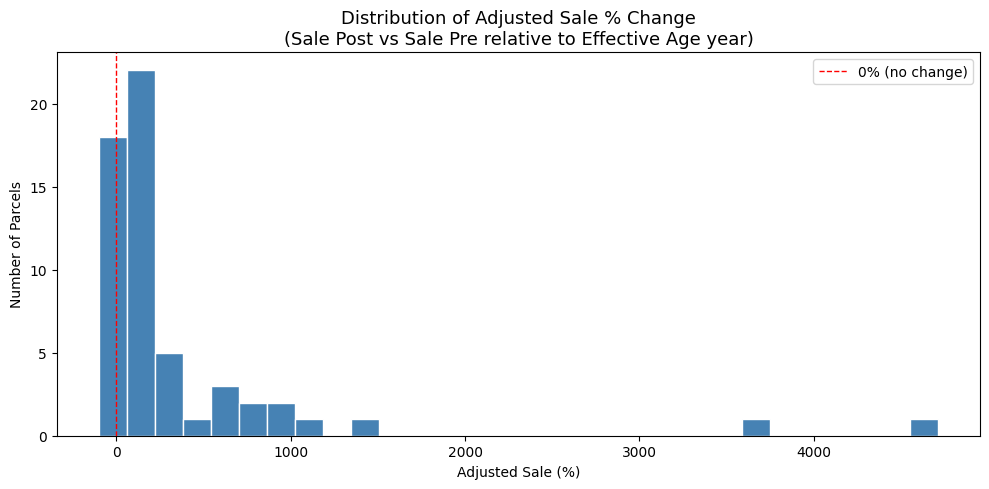

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Work only with rows that have valid Adjusted Sale
plot_df = df.dropna(subset=['Adjusted Sale']).copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(plot_df['Adjusted Sale'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='0% (no change)')
ax.set_title('Distribution of Adjusted Sale % Change\n(Sale Post vs Sale Pre relative to Effective Age year)', fontsize=13)
ax.set_xlabel('Adjusted Sale (%)')
ax.set_ylabel('Number of Parcels')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Chart 2 — Scatter: Delta vs Adjusted Sale %
# Delta = Effective Age − Year Built (renovation proxy).
# Explores whether buildings renovated closer to their sale date saw higher appreciation.

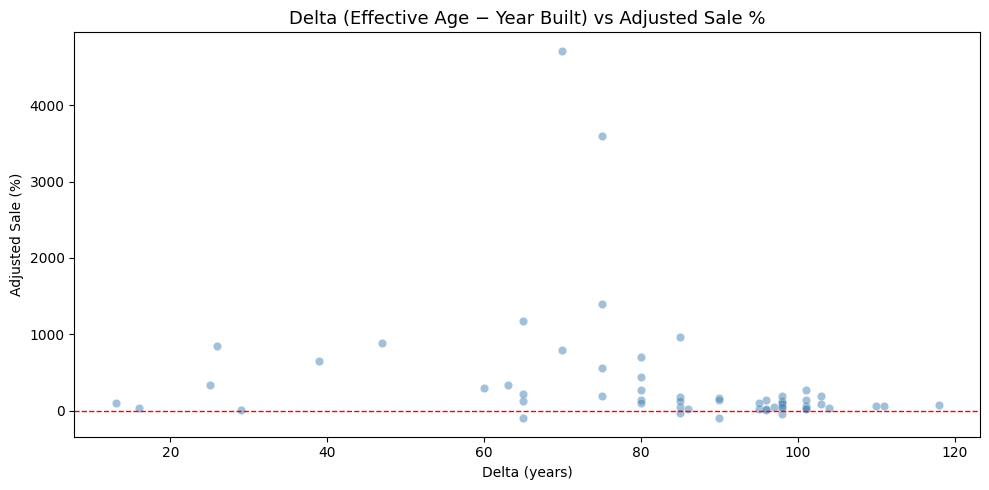

In [8]:
# Scatter: Delta vs Adjusted Sale
scatter_df = df.dropna(subset=['Delta', 'Adjusted Sale']).copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(scatter_df['Delta'], scatter_df['Adjusted Sale'],
           alpha=0.5, color='steelblue', edgecolors='white', linewidths=0.3)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Delta (Effective Age − Year Built) vs Adjusted Sale %', fontsize=13)
ax.set_xlabel('Delta (years)')
ax.set_ylabel('Adjusted Sale (%)')
plt.tight_layout()
plt.show()

In [ ]:
# Chart 3 — Bar: Avg Adjusted Sale % by Year Built Decade
# Groups parcels by construction decade to reveal era-based appreciation patterns.
# Green = positive avg appreciation, orange = negative.

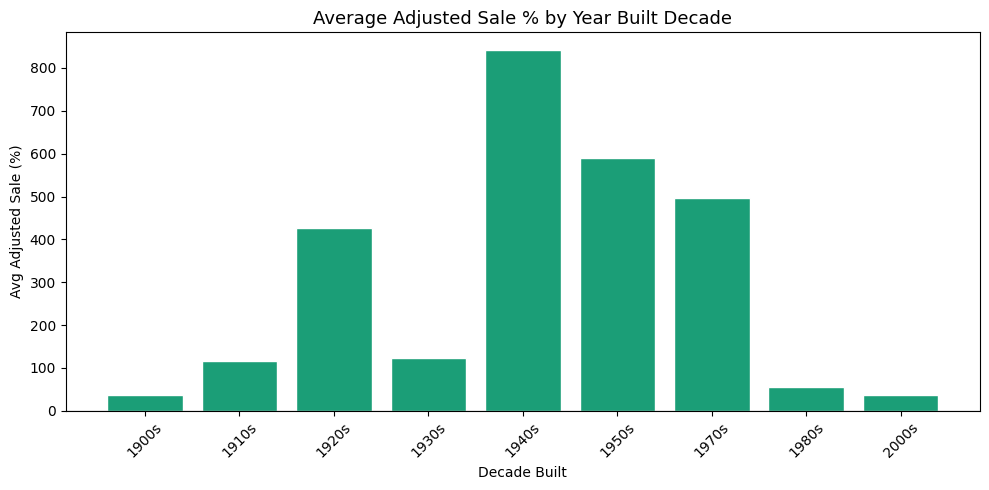

In [9]:
# Bar: Average Adjusted Sale by Year Built decade
decade_df = df.dropna(subset=['Year Built', 'Adjusted Sale']).copy()
decade_df['Decade'] = (decade_df['Year Built'] // 10 * 10).astype(int).astype(str) + 's'
decade_avg = decade_df.groupby('Decade')['Adjusted Sale'].mean().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d95f02' if v < 0 else '#1b9e77' for v in decade_avg.values]
ax.bar(decade_avg.index, decade_avg.values, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Adjusted Sale % by Year Built Decade', fontsize=13)
ax.set_xlabel('Decade Built')
ax.set_ylabel('Avg Adjusted Sale (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Chart 4 — Plotly Connected Dot Plot: Sale Pre & Post Price vs Delta
# Each parcel is a vertical line connecting its pre and post sale price.
# Hover shows ParcelID and both prices. Reveals magnitude and direction of price movement.

In [10]:
import plotly.graph_objects as go

fig = go.Figure()

# Draw a connecting line for each parcel
for _, row in df.iterrows():
    if pd.notna(row['Sale Pre Clean']) and pd.notna(row['Sale Post Clean']):
        fig.add_trace(go.Scatter(
            x=[row['Delta'], row['Delta']],
            y=[row['Sale Pre Clean'], row['Sale Post Clean']],
            mode='lines',
            line=dict(color='lightgray', width=1),
            showlegend=False,
            hoverinfo='skip'
        ))

# Sale Pre dots
fig.add_trace(go.Scatter(
    x=df['Delta'], y=df['Sale Pre Clean'],
    mode='markers', name='Sale Pre Price',
    marker=dict(color='steelblue', size=7, opacity=0.8),
    customdata=df[['ParcelID', 'Sale Post Clean']],
    hovertemplate='<b>%{customdata[0]}</b><br>Delta: %{x}<br>Sale Pre: $%{y:,.0f}<br>Sale Post: $%{customdata[1]:,.0f}<extra></extra>'
))

# Sale Post dots
fig.add_trace(go.Scatter(
    x=df['Delta'], y=df['Sale Post Clean'],
    mode='markers', name='Sale Post Price',
    marker=dict(color='darkorange', size=7, opacity=0.8),
    customdata=df[['ParcelID', 'Sale Pre Clean']],
    hovertemplate='<b>%{customdata[0]}</b><br>Delta: %{x}<br>Sale Post: $%{y:,.0f}<br>Sale Pre: $%{customdata[1]:,.0f}<extra></extra>'
))

fig.update_layout(
    title='Sale Pre & Post Price vs Delta — connected by Parcel',
    xaxis_title='Delta (years)',
    yaxis_title='Sale Price ($)',
    yaxis_tickformat='$,.0f',
    hovermode='closest',
    height=580
)

fig.show()


In [ ]:
# Chart 5 — Plotly Bar: Avg Adjusted Sale % by Bedrooms
# Checks whether bedroom count correlates with appreciation rate.
# Useful for identifying which property sizes benefit most from neighbourhood change.

In [11]:
import plotly.graph_objects as go

# Clean Bedrooms column to numeric
df['Bedrooms'] = pd.to_numeric(df['Bedrooms'], errors='coerce')

bed_df = df.dropna(subset=['Bedrooms', 'Adjusted Sale']).copy()
bed_df['Bedrooms'] = bed_df['Bedrooms'].astype(int)

avg_adjusted = bed_df.groupby('Bedrooms')['Adjusted Sale'].mean().reset_index()

fig = go.Figure(go.Bar(
    x=avg_adjusted['Bedrooms'],
    y=avg_adjusted['Adjusted Sale'],
    marker_color=['#d95f02' if v < 0 else '#1b9e77' for v in avg_adjusted['Adjusted Sale']],
    hovertemplate='Bedrooms: %{x}<br>Avg Adjusted Sale: %{y:.1f}%<extra></extra>'
))

fig.update_layout(
    title='Average Adjusted Sale % by Number of Bedrooms',
    xaxis_title='Number of Bedrooms',
    yaxis_title='Avg Adjusted Sale (%)',
    xaxis=dict(tickmode='linear'),
    height=500
)

fig.show()


In [ ]:
# Chart 6 — Plotly Bar: Avg Adjusted Sale % by Square Footage Range
# Bins properties into sqft ranges and compares average appreciation per bin.

In [12]:
import plotly.graph_objects as go

sqft_df = df.dropna(subset=['Square Feet', 'Adjusted Sale']).copy()
sqft_df['Square Feet'] = pd.to_numeric(sqft_df['Square Feet'], errors='coerce')
sqft_df = sqft_df.dropna(subset=['Square Feet'])

bins   = [0, 500, 1000, 1500, 2000, 2500, 3000, 4000, 5000, float('inf')]
labels = ['<500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-4000', '4000-5000', '5000+']

sqft_df['SqFt Range'] = pd.cut(sqft_df['Square Feet'], bins=bins, labels=labels)
avg_adjusted = sqft_df.groupby('SqFt Range', observed=True)['Adjusted Sale'].mean().reset_index()

fig = go.Figure(go.Bar(
    x=avg_adjusted['SqFt Range'].astype(str),
    y=avg_adjusted['Adjusted Sale'],
    marker_color=['#d95f02' if v < 0 else '#1b9e77' for v in avg_adjusted['Adjusted Sale']],
    hovertemplate='SqFt Range: %{x}<br>Avg Adjusted Sale: %{y:.1f}%<extra></extra>'
))

fig.update_layout(
    title='Average Adjusted Sale % by Square Feet Range',
    xaxis_title='Square Feet Range',
    yaxis_title='Avg Adjusted Sale (%)',
    height=500
)

fig.show()




In [ ]:
# Chart 7 — Plotly Bar: Avg Adjusted Sale % by Acres Range
# Same approach as sqft bar but for lot size (acres).
# Tests whether larger lots appreciate differently than smaller ones.

In [13]:
import plotly.graph_objects as go

acres_df = df.dropna(subset=['Acres', 'Adjusted Sale']).copy()
acres_df['Acres'] = pd.to_numeric(acres_df['Acres'], errors='coerce')
acres_df = acres_df.dropna(subset=['Acres'])

bins   = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 5.0, float('inf')]
labels = ['<0.1', '0.1-0.25', '0.25-0.5', '0.5-0.75', '0.75-1.0', '1.0-1.5', '1.5-2.0', '2.0-5.0', '5.0+']

acres_df['Acres Range'] = pd.cut(acres_df['Acres'], bins=bins, labels=labels)
avg_adjusted = acres_df.groupby('Acres Range', observed=True)['Adjusted Sale'].mean().reset_index()

fig = go.Figure(go.Bar(
    x=avg_adjusted['Acres Range'].astype(str),
    y=avg_adjusted['Adjusted Sale'],
    marker_color=['#d95f02' if v < 0 else '#1b9e77' for v in avg_adjusted['Adjusted Sale']],
    hovertemplate='Acres Range: %{x}<br>Avg Adjusted Sale: %{y:.1f}%<extra></extra>'
))

fig.update_layout(
    title='Average Adjusted Sale % by Acres Range',
    xaxis_title='Acres Range',
    yaxis_title='Avg Adjusted Sale (%)',
    height=500
)

fig.show()



In [ ]:
# Chart 8 — Plotly Parallel Coordinates
# Multi-dimensional view: Delta, Bedrooms, Sq Ft, Acres, and Adjusted Sale % on one plot.
# Colour-mapped to Adjusted Sale % (red→yellow→green). Drag axes to filter interactively.

In [14]:
import plotly.express as px

parallel_df = df.dropna(subset=['Delta', 'Bedrooms', 'Square Feet', 'Acres', 'Adjusted Sale']).copy()
parallel_df['Bedrooms']    = pd.to_numeric(parallel_df['Bedrooms'], errors='coerce')
parallel_df['Square Feet'] = pd.to_numeric(parallel_df['Square Feet'], errors='coerce')
parallel_df['Acres']       = pd.to_numeric(parallel_df['Acres'], errors='coerce')
parallel_df = parallel_df.dropna(subset=['Delta', 'Bedrooms', 'Square Feet', 'Acres', 'Adjusted Sale'])

fig = px.parallel_coordinates(
    parallel_df,
    dimensions=['Delta', 'Bedrooms', 'Square Feet', 'Acres', 'Adjusted Sale'],
    color='Adjusted Sale',
    color_continuous_scale=px.colors.diverging.RdYlGn,
    color_continuous_midpoint=0,
    labels={
        'Delta':         'Delta (yrs)',
        'Bedrooms':      'Bedrooms',
        'Square Feet':   'Sq Ft',
        'Acres':         'Acres',
        'Adjusted Sale': 'Adj Sale %'
    },
    title='Parallel Coordinates — Delta, Bedrooms, Sq Ft, Acres vs Adjusted Sale %'
)

fig.update_layout(height=550)
fig.show()


In [ ]:
# Chart 9 — Simple Linear Regression (one variable at a time)
# Fits OLS regression for each feature independently against Adjusted Sale %.
# 2×2 subplot grid with regression line and R² score per feature.
# Low R² values expected — linear relationships are weak; serves as a baseline.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import plotly.graph_objects as go
import plotly.subplots as sp
import numpy as np

reg_df = df.dropna(subset=['Delta', 'Bedrooms', 'Square Feet', 'Acres', 'Adjusted Sale']).copy()
reg_df['Bedrooms']    = pd.to_numeric(reg_df['Bedrooms'],    errors='coerce')
reg_df['Square Feet'] = pd.to_numeric(reg_df['Square Feet'], errors='coerce')
reg_df['Acres']       = pd.to_numeric(reg_df['Acres'],       errors='coerce')
reg_df = reg_df.dropna(subset=['Delta', 'Bedrooms', 'Square Feet', 'Acres', 'Adjusted Sale'])

features = ['Delta', 'Bedrooms', 'Square Feet', 'Acres']
y = reg_df['Adjusted Sale'].values

# ── 1. Simple Linear Regression — one variable at a time ─────────
print("=" * 50)
print("SIMPLE LINEAR REGRESSION")
print("=" * 50)

fig = sp.make_subplots(rows=2, cols=2,
    subplot_titles=[f'{f} vs Adjusted Sale %' for f in features])

positions = [(1,1), (1,2), (2,1), (2,2)]

for i, feature in enumerate(features):
    X = reg_df[feature].values.reshape(-1, 1)
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    print(f'\n{feature}:')
    print(f'  Coefficient : {model.coef_[0]:.4f}')
    print(f'  Intercept   : {model.intercept_:.4f}')
    print(f'  R² Score    : {r2:.4f}')

    row, col = positions[i]
    x_sorted = np.sort(reg_df[feature].values)
    y_line   = model.predict(x_sorted.reshape(-1, 1))

    fig.add_trace(go.Scatter(
        x=reg_df[feature], y=reg_df['Adjusted Sale'],
        mode='markers', marker=dict(color='steelblue', size=5, opacity=0.5),
        name=feature, showlegend=False,
        hovertemplate=f'{feature}: %{{x:.2f}}<br>Adj Sale: %{{y:.1f}}%<extra></extra>'
    ), row=row, col=col)

    fig.add_trace(go.Scatter(
        x=x_sorted, y=y_line,
        mode='lines', line=dict(color='red', width=2),
        name=f'R²={r2:.3f}', showlegend=False
    ), row=row, col=col)

    fig.add_annotation(
        text=f'R²={r2:.3f}', xref='paper', yref='paper',
        x=0.25*(i%2) + 0.1 + 0.5*(i%2), y=0.95 - 0.5*(i//2),
        showarrow=False, font=dict(color='red', size=11)
    )

fig.update_layout(title='Simple Linear Regression — Each Variable vs Adjusted Sale %', height=700)
fig.show()


# ── 2. Multiple Linear Regression — all variables together ───────
print("\n" + "=" * 50)
print("MULTIPLE LINEAR REGRESSION")
print("=" * 50)

X_multi = reg_df[features].values
model_multi = LinearRegression().fit(X_multi, y)
y_pred_multi = model_multi.predict(X_multi)
r2_multi = r2_score(y, y_pred_multi)

print(f'\nR² Score : {r2_multi:.4f}')
print(f'Intercept: {model_multi.intercept_:.4f}')
print('\nCoefficients:')
for f, c in zip(features, model_multi.coef_):
    print(f'  {f:<15}: {c:.4f}')

# Coefficient bar chart
fig2 = go.Figure(go.Bar(
    x=features,
    y=model_multi.coef_,
    marker_color=['#d95f02' if v < 0 else '#1b9e77' for v in model_multi.coef_],
    hovertemplate='%{x}<br>Coefficient: %{y:.4f}<extra></extra>'
))

fig2.update_layout(
    title=f'Multiple Linear Regression — Feature Coefficients (R²={r2_multi:.4f})',
    xaxis_title='Feature',
    yaxis_title='Coefficient',
    height=450
)
fig2.show()

# Actual vs Predicted
fig3 = go.Figure(go.Scatter(
    x=y, y=y_pred_multi,
    mode='markers',
    marker=dict(color='steelblue', size=6, opacity=0.6),
    hovertemplate='Actual: %{x:.1f}%<br>Predicted: %{y:.1f}%<extra></extra>'
))
fig3.add_trace(go.Scatter(
    x=[y.min(), y.max()], y=[y.min(), y.max()],
    mode='lines', line=dict(color='red', dash='dash'),
    name='Perfect fit', showlegend=True
))
fig3.update_layout(
    title='Multiple Regression — Actual vs Predicted Adjusted Sale %',
    xaxis_title='Actual Adjusted Sale %',
    yaxis_title='Predicted Adjusted Sale %',
    height=500
)
fig3.show()


SIMPLE LINEAR REGRESSION

Delta:
  Coefficient : -6.5635
  Intercept   : 905.2916
  R² Score    : 0.0397

Bedrooms:
  Coefficient : -32.8287
  Intercept   : 481.6917
  R² Score    : 0.0016

Square Feet:
  Coefficient : -0.0382
  Intercept   : 453.8265
  R² Score    : 0.0012

Acres:
  Coefficient : 1813.1896
  Intercept   : 102.6769
  R² Score    : 0.0155



MULTIPLE LINEAR REGRESSION

R² Score : 0.0624
Intercept: 727.5101

Coefficients:
  Delta          : -6.4444
  Bedrooms       : -31.9920
  Square Feet    : -0.0413
  Acres          : 2401.1205


In [ ]:
# ── Section 6: Interactive Filter Dashboard ───────────────────────────────────
# ipywidgets-powered dashboard for exploratory filtering.
# Controls: bedroom multi-select, square footage range, effective age range, year built range.
# Pressing "Apply Filters" re-renders all 4 panels for the filtered subset.
# Panels: (1) Sale Pre/Post vs Delta, (2) Beds bar, (3) Sq Ft bar, (4) Acres bar.

In [29]:
# ── Section 6: Interactive Filter Dashboard ───────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np, pandas as pd

# ── prep ──────────────────────────────────────────────────────────────────
dash_df = df.copy()
dash_df['Square Feet'] = pd.to_numeric(
    dash_df['Square Feet'].astype(str).str.replace(',','',regex=False), errors='coerce')
dash_df['Acres']    = pd.to_numeric(dash_df['Acres'],    errors='coerce')
dash_df['Bedrooms'] = pd.to_numeric(dash_df['Bedrooms'], errors='coerce')
dash_df = dash_df[dash_df['Delta'].notna() & (dash_df['Delta'] >= 0)]
dash_df = dash_df.dropna(subset=['Sale Pre Clean','Sale Post Clean'])

# ── widget ranges ─────────────────────────────────────────────────────────
bed_opts = sorted([int(b) for b in dash_df['Bedrooms'].dropna().unique() if b > 0])
sqft_min = int(dash_df['Square Feet'].min(skipna=True))
sqft_max = int(dash_df['Square Feet'].max(skipna=True))
age_min  = int(dash_df['Effective Age'].min(skipna=True))
age_max  = int(dash_df['Effective Age'].max(skipna=True))
yb_min   = int(dash_df['Year Built'].min(skipna=True))
yb_max   = int(dash_df['Year Built'].max(skipna=True))

# ── widgets ───────────────────────────────────────────────────────────────
w_beds = widgets.SelectMultiple(
    options=bed_opts, value=bed_opts,
    description='Beds:', rows=min(6, len(bed_opts)),
    layout=widgets.Layout(width='160px')
)
w_sqft = widgets.IntRangeSlider(
    value=[sqft_min, sqft_max], min=sqft_min, max=sqft_max, step=100,
    description='Sq Ft:', continuous_update=False,
    layout=widgets.Layout(width='420px')
)
w_age = widgets.IntRangeSlider(
    value=[age_min, age_max], min=age_min, max=age_max, step=1,
    description='Eff Age:', continuous_update=False,
    layout=widgets.Layout(width='420px')
)
w_yb = widgets.IntRangeSlider(
    value=[yb_min, yb_max], min=yb_min, max=yb_max, step=1,
    description='Yr Built:', continuous_update=False,
    layout=widgets.Layout(width='420px')
)
btn        = widgets.Button(description='Apply Filters', button_style='primary',
                            layout=widgets.Layout(width='160px', height='36px'))
status_lbl = widgets.Label(value='')
chart_out  = widgets.Output()

controls = widgets.VBox([
    widgets.HTML('<h3 style="margin:6px 0">Property Appreciation Analysis Dashboard</h3>'),
    widgets.HBox([
        widgets.VBox([widgets.Label('Bedrooms:'), w_beds]),
        widgets.VBox([w_sqft, w_age, w_yb, widgets.HBox([btn, status_lbl])])
    ]),
    chart_out
])

# ── draw dashboard ────────────────────────────────────────────────────────
def draw_dashboard(fdf):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('Property Appreciation Analysis Dashboard', fontsize=15, fontweight='bold')

            # Panel 1 — Sale Pre vs Sale Post price vs Delta (connected by parcel)
    ax = axes[0, 0]
    p1 = fdf.dropna(subset=['Delta', 'Sale Pre Clean', 'Sale Post Clean']).copy()

    if len(p1):
        # connecting lines
        for _, row in p1.iterrows():
            ax.plot([row['Delta'], row['Delta']],
                    [row['Sale Pre Clean'], row['Sale Post Clean']],
                    color='lightgray', linewidth=0.8, zorder=1)
        # Sale Pre dots
        ax.scatter(p1['Delta'], p1['Sale Pre Clean'],
                   color='steelblue', s=40, alpha=0.8, zorder=2, label='Sale Pre Price',
                   edgecolors='white', linewidths=0.3)
        # Sale Post dots
        ax.scatter(p1['Delta'], p1['Sale Post Clean'],
                   color='darkorange', s=40, alpha=0.8, zorder=2, label='Sale Post Price',
                   edgecolors='white', linewidths=0.3)
        ax.legend(fontsize=8)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title('Sale Pre & Post Price vs Delta')
    ax.set_xlabel('Delta (years)'); ax.set_ylabel('Sale Price ($)')


    # Panel 2 — Bedrooms bar
    ax = axes[0, 1]
    p2 = fdf.dropna(subset=['Bedrooms','Adjusted Sale'])
    p2 = p2[p2['Bedrooms'] > 0]
    if len(p2):
        grp2 = p2.groupby('Bedrooms')['Adjusted Sale'].mean()
        colors = ['#d95f02' if v < 0 else '#1b9e77' for v in grp2]
        ax.bar(grp2.index.astype(int).astype(str), grp2.values, color=colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title('Avg Adjusted Sale % by Bedrooms')
    ax.set_xlabel('Bedrooms'); ax.set_ylabel('Avg Adjusted Sale (%)')

    # Panel 3 — Square Feet bar
    ax = axes[1, 0]
    p3 = fdf.dropna(subset=['Square Feet','Adjusted Sale']).copy()
    if len(p3) >= 2:
        try:
            p3['Bin'] = pd.cut(p3['Square Feet'], bins=5)
            grp3 = p3.groupby('Bin', observed=True)['Adjusted Sale'].mean()
            labels = [str(b) for b in grp3.index]
            colors = ['#d95f02' if v < 0 else '#1b9e77' for v in grp3]
            ax.bar(range(len(grp3)), grp3.values, color=colors, edgecolor='white')
            ax.set_xticks(range(len(grp3)))
            ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
        except Exception: pass
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title('Avg Adjusted Sale % by Sq Ft')
    ax.set_ylabel('Avg Adjusted Sale (%)')

    # Panel 4 — Acres bar
    ax = axes[1, 1]
    p4 = fdf.dropna(subset=['Acres','Adjusted Sale']).copy()
    if len(p4) >= 2:
        try:
            p4['Bin'] = pd.cut(p4['Acres'], bins=5)
            grp4 = p4.groupby('Bin', observed=True)['Adjusted Sale'].mean()
            labels = [str(b) for b in grp4.index]
            colors = ['#d95f02' if v < 0 else '#1b9e77' for v in grp4]
            ax.bar(range(len(grp4)), grp4.values, color=colors, edgecolor='white')
            ax.set_xticks(range(len(grp4)))
            ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
        except Exception: pass
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title('Avg Adjusted Sale % by Acres')
    ax.set_ylabel('Avg Adjusted Sale (%)')

    plt.tight_layout()

    with chart_out:
        clear_output(wait=True)
        plt.show()

# ── button ────────────────────────────────────────────────────────────────
def on_apply(b):
    beds   = list(w_beds.value)
    sq_lo, sq_hi = w_sqft.value
    ag_lo, ag_hi = w_age.value
    yb_lo, yb_hi = w_yb.value
    fdf = dash_df[dash_df['Bedrooms'].isin(beds)]
    fdf = fdf[fdf['Square Feet'].between(sq_lo, sq_hi) | fdf['Square Feet'].isna()]
    fdf = fdf[fdf['Effective Age'].between(ag_lo, ag_hi) | fdf['Effective Age'].isna()]
    fdf = fdf[fdf['Year Built'].between(yb_lo, yb_hi) | fdf['Year Built'].isna()]
    status_lbl.value = f'  Filtered: {len(fdf)} parcels'
    draw_dashboard(fdf)

btn.on_click(on_apply)

display(controls)
draw_dashboard(dash_df)
